In [48]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [31]:
import pandas as pd

df = pd.read_csv("sp500_dataset.csv")
df = df.sort_values(["Ticker","Datetime"])
df["Target"] = df.groupby("Datetime")["Target"].transform(
    lambda x: x - x.mean()
)
print(df.shape)
print(df["Ticker"].nunique())
print(df["Datetime"].min(), df["Datetime"].max())

(336438, 22)
488
2020-08-24 04:00:00+00:00 2026-03-04 05:00:00+00:00


In [32]:
df.groupby("Datetime")["Ticker"].count().describe()

count    1388.000000
mean      242.390490
std        64.698148
min        20.000000
25%       202.000000
50%       236.000000
75%       282.000000
max       439.000000
Name: Ticker, dtype: float64

In [34]:
features = [
    "Return_1",
    "Return_5",
    "Return_10",
    "Momentum_20",
    "MA_ratio",
    "Volatility_10",
    "RSI",
    "CS_Return_Rank",
    "CS_Vol_Rank"
]

df[features] = df.groupby("Datetime")[features].transform(
    lambda x: (x - x.mean()) / x.std()
)

In [46]:
split_date = "2024-01-01"

train = df[df["Datetime"] < split_date]
test  = df[df["Datetime"] >= split_date]

In [50]:
import lightgbm as lgb

model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8
)



X_train = train[features]
y_train = train["Target"]

model.fit(X_train, y_train)
test["prediction"] = model.predict(test[features])


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001502 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 185058, number of used features: 9
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

In [ ]:
test["prediction"] = model.predict(test[features])

In [51]:
ic = test.groupby("Datetime").apply(
    lambda x: x["prediction"].corr(x["Target"])
)

print("Mean IC:", ic.mean())

Mean IC: 0.017346257556302976


<Axes: xlabel='decile'>

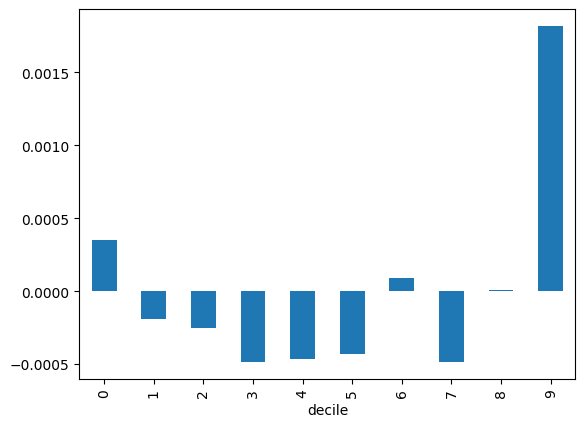

In [53]:
test["decile"] = test.groupby("Datetime")["prediction"].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates="drop")
)

decile_returns = test.groupby("decile")["Target"].mean()

decile_returns.plot(kind="bar")